Çapraz doğrulama başladı...

✔ Lojistik Regresyon tamamlandı
✔ Destek Vektör Mak. tamamlandı
✔ Rastgele Orman tamamlandı
✔ XGBoost tamamlandı

── Performans Tablosu ──────────────────────────────
                    Doğruluk  Kesinlik  Duyarlılık  F1-Skoru  ROC-AUC
Lojistik Regresyon    0.8076    0.5675      0.8462    0.6793   0.9050
Destek Vektör Mak.    0.7945    0.5477      0.8448    0.6645   0.8971
Rastgele Orman        0.8374    0.6546      0.6884    0.6709   0.8893
XGBoost               0.8539    0.6715      0.7707    0.7176   0.9227


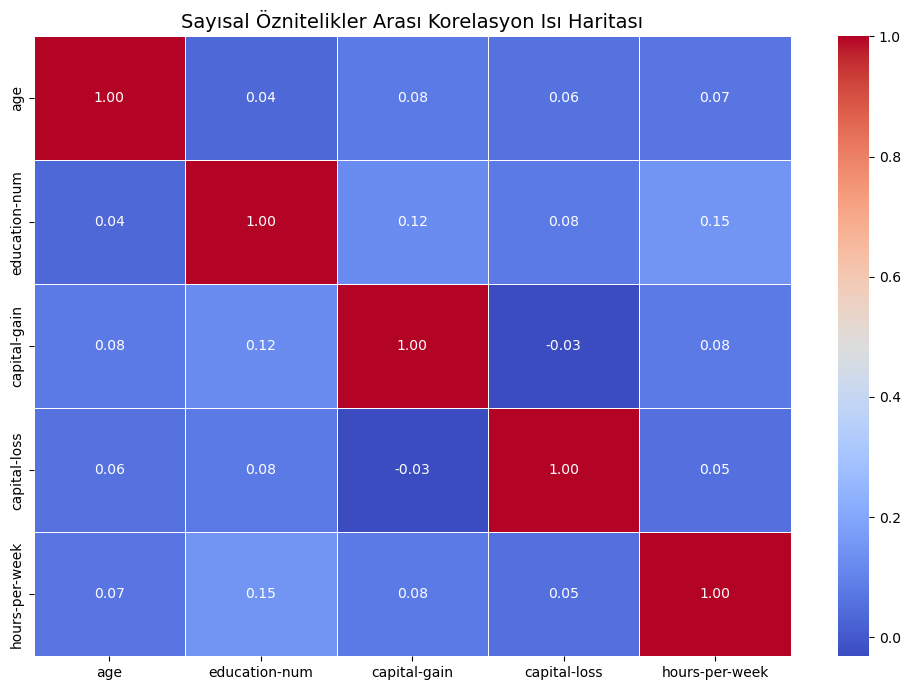

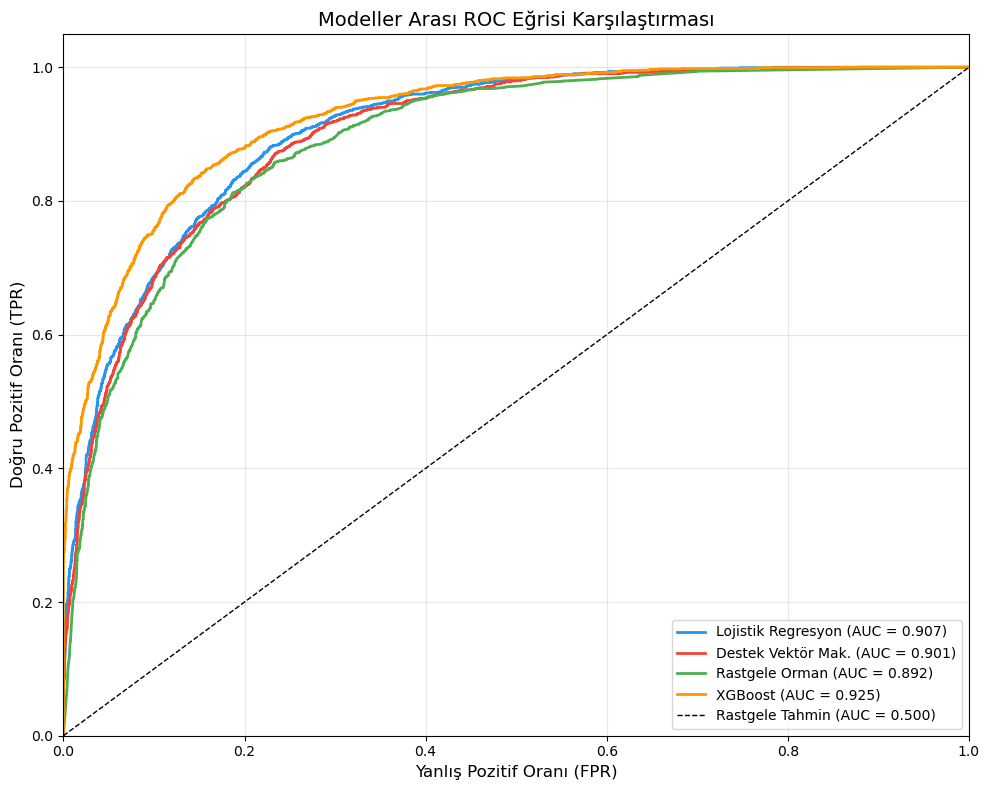

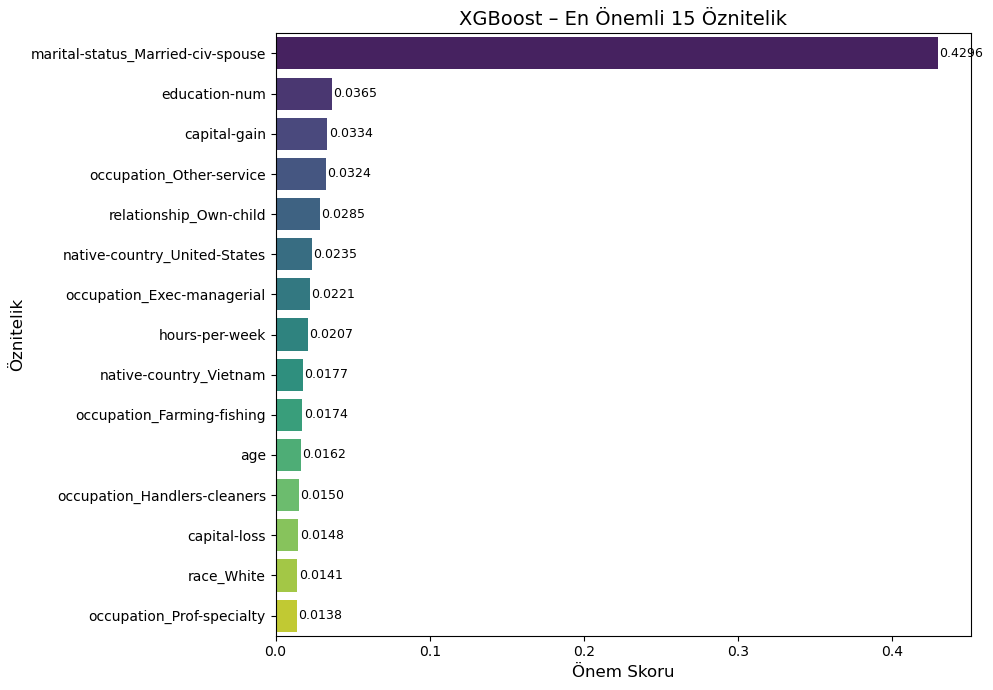

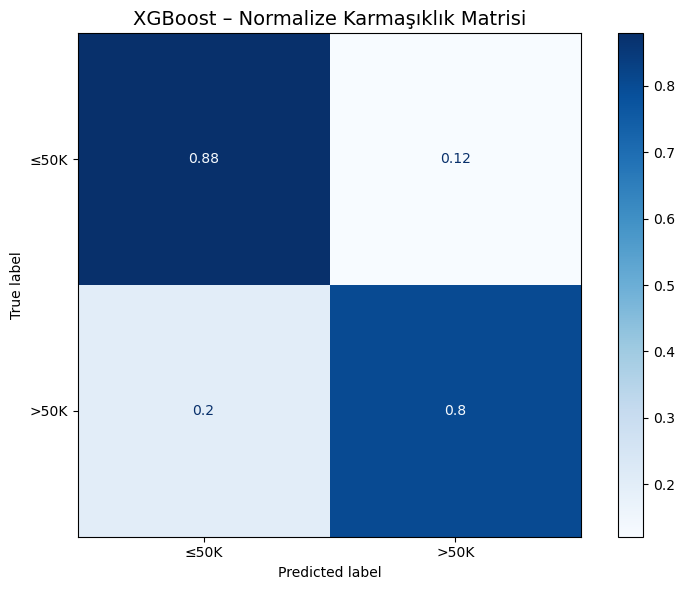

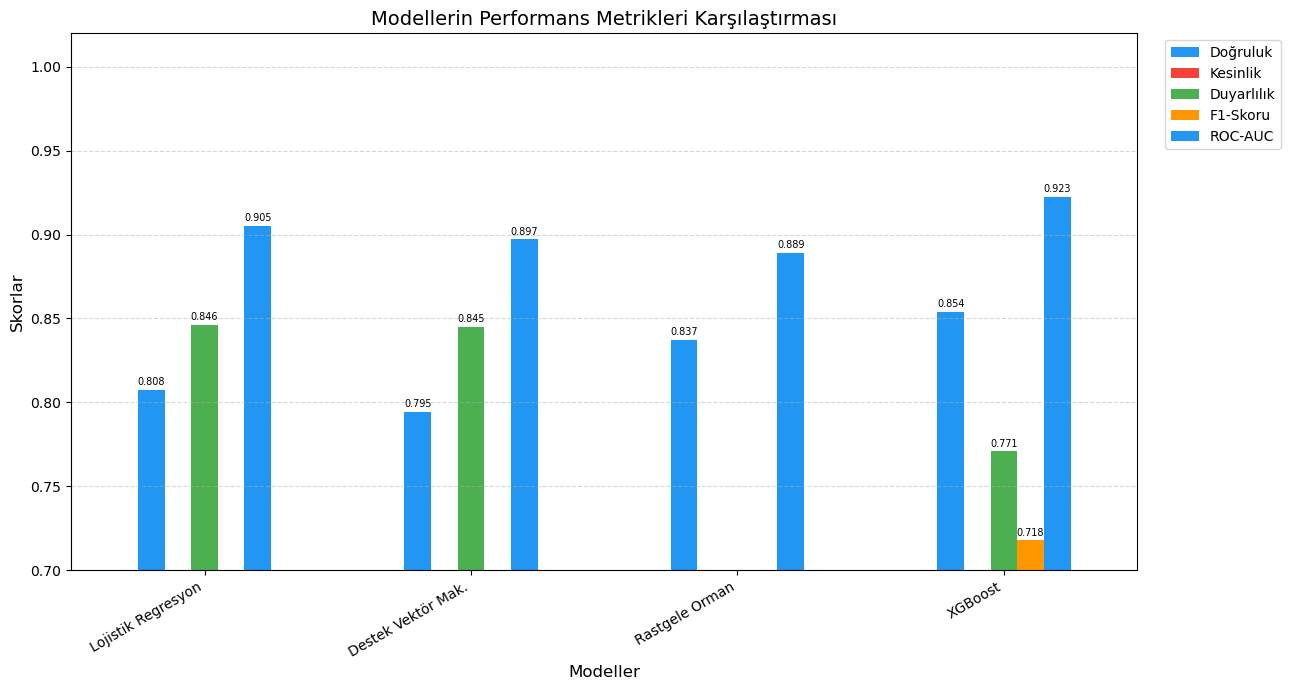


✅ Tüm görseller kaydedildi (01–05 .png)


In [1]:
"""
Binary Sınıflandırma Problemlerinde Farklı Makine Öğrenmesi
Algoritmalarının Performans Analizi ve Karşılaştırılması
─────────────────────────────────────────────────────────
Veri Seti : UCI Adult (Census Income) – 48 842 örnek, 14 öznitelik
Hedef     : Yıllık gelir > 50K$ mı? (Binary sınıflandırma)
"""

# ── 0. KÜTÜPHANELER ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    RepeatedStratifiedKFold, cross_validate, train_test_split
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ── 1. VERİ YÜKLEME VE TEMİZLEME ─────────────────────────────────────────────
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv(
    "adult.data",
    header=None,
    names=columns,
    na_values=" ?",
    skipinitialspace=True
)

df = df.dropna()

# 'education' → 'education-num' ile aynı bilgiyi taşır; kaldırılır.
# 'fnlwgt'    → istatistiksel ağırlık faktörü; sınıflandırma için anlamsız.
df = df.drop(columns=['education', 'fnlwgt'])

X = df.drop('income', axis=1)
y = (df['income'] == '>50K').astype(int)   # 0: ≤50K  |  1: >50K

# ── 2. ÖN İŞLEME ──────────────────────────────────────────────────────────────
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), num_cols),                          # Mesafeye dayalı modeller için
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)  # Kategorik encoding
])

# ── 3. MODELLER ────────────────────────────────────────────────────────────────
models = {
    'Lojistik Regresyon' : LogisticRegression(max_iter=1000),
    'Destek Vektör Mak.' : SVC(probability=True),              # ROC için probability=True
    'Rastgele Orman'     : RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost'            : XGBClassifier(eval_metric='logloss', random_state=42)
}

COLORS = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

# ── 4. ÇAPRAZ DOĞRULAMA (10-Kat Tekrarlı Stratified K-Fold) ───────────────────
cv      = RepeatedStratifiedKFold(n_splits=10, n_repeats=1, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results = {}

print("Çapraz doğrulama başladı...\n")
for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote',        SMOTE(random_state=42)),   # Sınıf dengesizliği giderimi
        ('classifier',   model)
    ])

    cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    results[name] = {
        'Doğruluk'  : np.mean(cv_results['test_accuracy']),
        'Kesinlik'  : np.mean(cv_results['test_precision']),
        'Duyarlılık': np.mean(cv_results['test_recall']),
        'F1-Skoru'  : np.mean(cv_results['test_f1']),
        'ROC-AUC'   : np.mean(cv_results['test_roc_auc'])
    }
    print(f"✔ {name} tamamlandı")

results_df = pd.DataFrame(results).T
print("\n── Performans Tablosu ──────────────────────────────")
print(results_df.round(4).to_string())

# ── 5. GÖRSEL 1 – Korelasyon Isı Haritası (Sayısal Öznitelikler) ──────────────
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Sayısal Öznitelikler Arası Korelasyon Isı Haritası', fontsize=14)
plt.tight_layout()
plt.savefig('01_korelasyon_haritasi.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 6. GÖRSEL 2 – ROC Eğrisi Karşılaştırması ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

plt.figure(figsize=(10, 8))

for (name, model), color in zip(models.items(), COLORS):
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote',        SMOTE(random_state=42)),
        ('classifier',   model)
    ])
    pipe.fit(X_train, y_train)

    y_probs  = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc  = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin (AUC = 0.500)', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=12)
plt.ylabel('Doğru Pozitif Oranı (TPR)', fontsize=12)
plt.title('Modeller Arası ROC Eğrisi Karşılaştırması', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('02_roc_karsilastirma.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 7. GÖRSEL 3 – XGBoost Öznitelik Önemi ─────────────────────────────────────
# Not: Yorumlanabilirlik amacıyla tüm veri üzerinde eğitilmektedir.
xgb_full = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   XGBClassifier(eval_metric='logloss', random_state=42))
])
xgb_full.fit(X, y)

ohe_features    = xgb_full.named_steps['preprocessor']\
                           .named_transformers_['cat']\
                           .get_feature_names_out(cat_cols)
all_features    = num_cols + list(ohe_features)
importances     = xgb_full.named_steps['classifier'].feature_importances_

feat_df = (pd.DataFrame({'Öznitelik': all_features, 'Önem': importances})
             .sort_values('Önem', ascending=False)
             .head(15))

# Uzun OHE isimlerini kısalt
feat_df['Öznitelik'] = feat_df['Öznitelik'].str.replace(r'^cat_\d+__', '', regex=True).str[:35]

plt.figure(figsize=(10, 7))
ax = sns.barplot(x='Önem', y='Öznitelik', data=feat_df, palette='viridis')

for i, v in enumerate(feat_df['Önem']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.title('XGBoost – En Önemli 15 Öznitelik', fontsize=14)
plt.xlabel('Önem Skoru', fontsize=12)
plt.ylabel('Öznitelik', fontsize=12)
plt.tight_layout()
plt.savefig('03_oznitelik_onem.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 8. GÖRSEL 4 – XGBoost Karmaşıklık Matrisi ────────────────────────────────
# Ayrı pipeline – sadece eğitim verisiyle fit edilir (veri sızıntısı yok)
xgb_clean = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   XGBClassifier(eval_metric='logloss', random_state=42))
])
xgb_clean.fit(X_train, y_train)
y_pred = xgb_clean.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['≤50K', '>50K'],
    cmap='Blues',
    normalize='true',    # Sınıf dengesizliği nedeniyle normalize edilmiştir
    ax=ax
)
plt.title('XGBoost – Normalize Karmaşıklık Matrisi', fontsize=14)
plt.tight_layout()
plt.savefig('04_karisiklik_matrisi.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 9. GÖRSEL 5 – Performans Metrikleri Çubuk Grafiği ─────────────────────────
ax2 = results_df.plot(kind='bar', figsize=(13, 7), color=COLORS[:len(results_df.columns)])

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', fontsize=7, padding=2)

plt.title('Modellerin Performans Metrikleri Karşılaştırması', fontsize=14)
plt.xlabel('Modeller', fontsize=12)
plt.ylabel('Skorlar', fontsize=12)
plt.ylim(0.70, 1.02)
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('05_performans_karsilastirma.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Tüm görseller kaydedildi (01–05 .png)")